# Notebook 3: Appendix
**Project:** Household-Level Coupon A/B Test Design
**Dataset:** dunnhumby - The Complete Journey

This appendix contains supporting artifacts referenced in the experiment design (Notebook 2).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

os.chdir(r"C:\Users\David Cho\OneDrive\Desktop\Projects\AB Testing\Experiment Design\The Complete Journey")
DATA_DIR = './data/'
hh = pd.read_csv(DATA_DIR + 'hh_features.csv')
print(f"Loaded: {hh.shape}")

Loaded: (2498, 50)


---
## Appendix A: Baseline Summary Table by Proposed Strata

This table shows the mean and standard deviation of key covariates within each stratification cell (spend tier x recency band). It confirms that strata capture meaningful behavioral variation.

In [41]:
# Apply eligibility filters
eligible = hh[
    (hh['total_trips'] >= 2) & 
    (hh['recency_days'] <= 90) & 
    (hh['n_campaigns_received'] >= 1)
].copy()

# Build 4-week total spend from post-period transactions
txn_all = pd.read_csv(DATA_DIR + 'transaction_data.csv')
POST_START, POST_END = 72, 102
EXPERIMENT_WEEKS = 4

eligible_keys = set(eligible['household_key'])
txn_post = txn_all[(txn_all['WEEK_NO'].between(POST_START, POST_END)) & 
                    (txn_all['household_key'].isin(eligible_keys))]

weekly_hh = (txn_post.groupby(['household_key', 'WEEK_NO'])
             .agg(weekly_spend=('SALES_VALUE', 'sum'),
                  weekly_trips=('BASKET_ID', 'nunique'))
             .reset_index())

# Representative 4-week window from the middle of post-period
post_weeks = sorted(weekly_hh['WEEK_NO'].unique())
mid_idx = len(post_weeks) // 2
ws_mid, we_mid = post_weeks[mid_idx - 2], post_weeks[mid_idx + 1]

hh_4wk = weekly_hh[weekly_hh['WEEK_NO'].between(ws_mid, we_mid)].groupby('household_key').agg(
    spend_4wk=('weekly_spend', 'sum'),
    trips_4wk=('weekly_trips', 'sum'),
).reset_index()

eligible = eligible.merge(hh_4wk, on='household_key', how='left')
eligible['spend_4wk'] = eligible['spend_4wk'].fillna(0)
eligible['trips_4wk'] = eligible['trips_4wk'].fillna(0)
eligible['pre_spend_4wk'] = eligible['avg_weekly_spend'] * EXPERIMENT_WEEKS

print(f"Eligible households: {len(eligible)}")
print(f"Representative 4-week window: Week {ws_mid}–{we_mid}\n")

# Summary by spend tier
print("=" * 80)
print("BASELINE BY SPEND TIER")
print("=" * 80)
spend_summary = eligible.groupby('spend_tier').agg(
    n_households=('household_key', 'count'),
    pre_spend_4wk_mean=('pre_spend_4wk', 'mean'),
    pre_spend_4wk_std=('pre_spend_4wk', 'std'),
    total_trips_mean=('total_trips', 'mean'),
    total_trips_std=('total_trips', 'std'),
    coupon_usage_rate_mean=('coupon_usage_rate', 'mean'),
    coupon_usage_rate_std=('coupon_usage_rate', 'std'),
    recency_days_mean=('recency_days', 'mean'),
    recency_days_std=('recency_days', 'std'),
    post_spend_4wk_mean=('spend_4wk', 'mean'),
    post_spend_4wk_std=('spend_4wk', 'std')
)

print(spend_summary.round(2))

# Summary by recency band
print("\n" + "=" * 80)
print("BASELINE BY RECENCY BAND")
print("=" * 80)
recency_summary = eligible.groupby('recency_band').agg(
    n_households=('household_key', 'count'),
    pre_spend_4wk_mean=('pre_spend_4wk', 'mean'),
    pre_spend_4wk_std=('pre_spend_4wk', 'std'),
    total_trips_mean=('total_trips', 'mean'),
    total_trips_std=('total_trips', 'std'),
    coupon_usage_rate_mean=('coupon_usage_rate', 'mean'),
    coupon_usage_rate_std=('coupon_usage_rate', 'std'),
    post_spend_4wk_mean=('spend_4wk', 'mean'),
    post_spend_4wk_std=('spend_4wk', 'std')
)
print(recency_summary.round(2))

Eligible households: 1288
Representative 4-week window: Week 85–88

BASELINE BY SPEND TIER
             n_households  pre_spend_4wk_mean  pre_spend_4wk_std  \
spend_tier                                                         
High                  573              332.90             145.57   
Low                    23               28.90               5.78   
Medium-High           458              133.38              27.28   
Medium-Low            234               67.64              15.29   

             total_trips_mean  total_trips_std  coupon_usage_rate_mean  \
spend_tier                                                               
High                   154.97           108.97                    0.02   
Low                     47.04            18.68                    0.02   
Medium-High             83.36            45.72                    0.01   
Medium-Low              59.99            38.33                    0.01   

             coupon_usage_rate_std  recency_days_mean  

=== Strata Cross-Tabulation (4-Week Spend) ===
                            n  pre_spend_4wk  post_spend_4wk
spend_tier  recency_band                                    
High        0-7d          487         342.19          328.20
            31-90d          8         257.04          155.13
            8-30d          78         282.66          285.47
Low         0-7d           10          30.52           41.06
            31-90d          6          26.42           62.60
            8-30d           7          28.71           52.91
Medium-High 0-7d          318         135.72          158.33
            31-90d         21         119.48          122.55
            8-30d         119         129.59          121.15
Medium-Low  0-7d          127          69.40           90.17
            31-90d         24          66.99           67.14
            8-30d          83          65.13           69.91


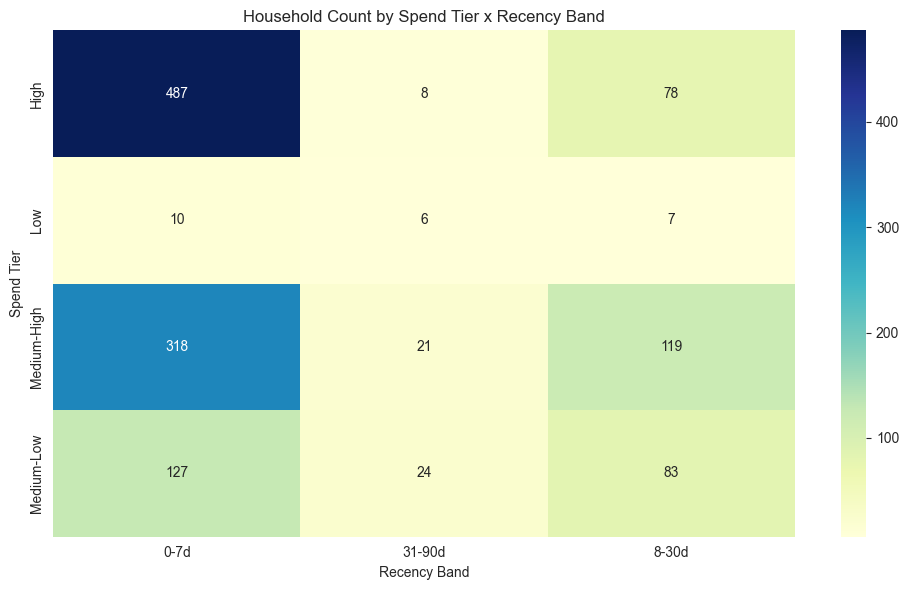

In [43]:
# Cross-tabulation: Spend Tier x Recency Band
cross_tab = eligible.groupby(['spend_tier', 'recency_band']).agg(
    n = ('household_key', 'count'),
    pre_spend_4wk = ('pre_spend_4wk', 'mean'),
    post_spend_4wk = ('spend_4wk', 'mean'),
).round(2)

print("=== Strata Cross-Tabulation (4-Week Spend) ===")
print(cross_tab)

# Heatmap of household counts by strata
pivot = eligible.groupby(['spend_tier', 'recency_band']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Household Count by Spend Tier x Recency Band')
ax.set_ylabel('Spend Tier')
ax.set_xlabel('Recency Band')
plt.tight_layout()
plt.show()

---
## Appendix B: Sample-Size Calculation Sheet for Multiple MDE Scenarios

This sensitivity analysis shows how the required sample size changes across different MDE values, variance assumptions, and power levels. All values use **4-week total spend** as the outcome to match the experiment design.

### Formula

For a two-sample t-test with equal allocation:

$$n_{\text{per arm}} = \frac{2\sigma^2 (z_{1-\alpha/2} + z_{1-\beta})^2}{\delta^2}$$

For CUPED-adjusted variance:

$$n_{\text{per arm}}^{\text{CUPED}} = \frac{2\sigma_{\text{CUPED}}^2 (z_{1-\alpha/2} + z_{1-\beta})^2}{\delta^2}$$

where $\sigma_{\text{CUPED}}^2 = \sigma^2(1 - \rho^2)$ and $\rho$ is the pre-post correlation.

In [46]:
def sample_size_per_arm(sigma, delta, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n = 2 * (sigma ** 2) * (z_alpha + z_beta) ** 2 / (delta ** 2)
    return int(np.ceil(n))

# Variance estimates on 4-week total spend (ITT: all eligible, zeros included)
outcome_4wk = eligible['spend_4wk']
outcome_4wk_win = outcome_4wk.clip(lower=outcome_4wk.quantile(0.01),
                                    upper=outcome_4wk.quantile(0.99))
X_pre_4wk = eligible['pre_spend_4wk']

rho = X_pre_4wk.corr(outcome_4wk)
theta = np.cov(outcome_4wk, X_pre_4wk)[0, 1] / np.var(X_pre_4wk)
Y_cuped = outcome_4wk - theta * (X_pre_4wk - X_pre_4wk.mean())

sigma_raw = outcome_4wk.std()
sigma_win = outcome_4wk_win.std()
sigma_cuped = Y_cuped.std()

# MDE range in 4-week total dollars
mde_values = [4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 20.0, 24.0, 32.0, 40.0]
power_levels = [0.80, 0.90]

N_eligible = len(eligible)

print("=" * 105)
print("SAMPLE SIZE PER ARM — Full Sensitivity Analysis (4-Week Total Spend)")
print(f"α = 0.05, Two-sided | N eligible = {N_eligible}")
print(f"σ_raw = ${sigma_raw:.2f} | σ_win = ${sigma_win:.2f} | σ_CUPED = ${sigma_cuped:.2f} | ρ = {rho:.3f}")
print("=" * 105)

for pwr in power_levels:
    print(f"\n--- Power = {pwr:.0%} ---")
    print(f"{'MDE ($/4wk)':<14} {'~$/wk':<10} {'n (raw)':<12} {'n (win)':<12} {'n (CUPED)':<12} {'Total (CUPED)':<15} {'Feasible?':<10}")
    print("-" * 85)
    for mde in mde_values:
        n_raw = sample_size_per_arm(sigma_raw, mde, 0.05, pwr)
        n_win = sample_size_per_arm(sigma_win, mde, 0.05, pwr)
        n_cup = sample_size_per_arm(sigma_cuped, mde, 0.05, pwr)
        total = n_cup * 2
        feasible = "Yes" if total <= N_eligible else "No"
        print(f"${mde:<12.0f} ~${mde/4:<8.2f} {n_raw:<12,} {n_win:<12,} {n_cup:<12,} {total:<15,} {feasible:<10}")
    print()

SAMPLE SIZE PER ARM — Full Sensitivity Analysis (4-Week Total Spend)
α = 0.05, Two-sided | N eligible = 1288
σ_raw = $188.81 | σ_win = $183.18 | σ_CUPED = $138.01 | ρ = 0.682

--- Power = 80% ---
MDE ($/4wk)    ~$/wk      n (raw)      n (win)      n (CUPED)    Total (CUPED)   Feasible? 
-------------------------------------------------------------------------------------
$4            ~$1.00     34,976       32,921       18,687       37,374          No        
$6            ~$1.50     15,545       14,632       8,306        16,612          No        
$8            ~$2.00     8,744        8,231        4,672        9,344           No        
$10           ~$2.50     5,597        5,268        2,990        5,980           No        
$12           ~$3.00     3,887        3,658        2,077        4,154           No        
$14           ~$3.50     2,856        2,688        1,526        3,052           No        
$16           ~$4.00     2,186        2,058        1,168        2,336           

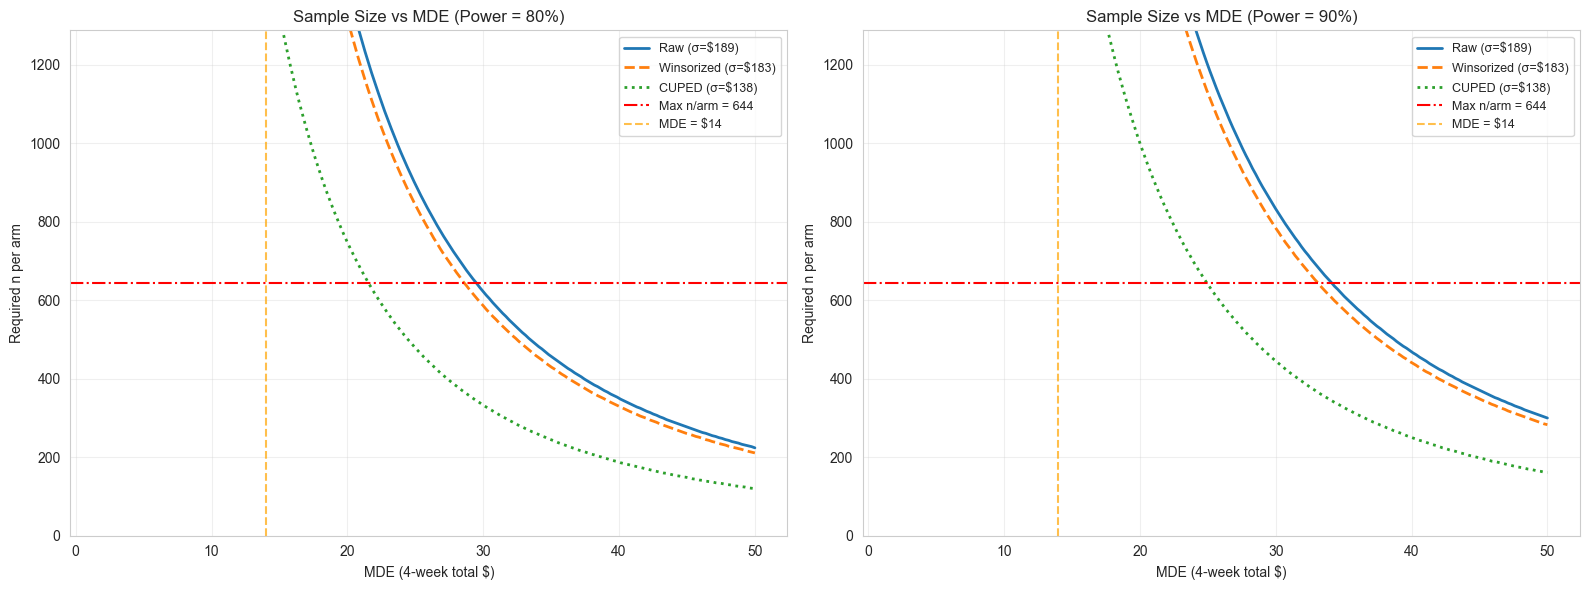

In [48]:
# Visualization: Sample size sensitivity
mde_fine = np.linspace(2, 50, 200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for pwr, ax in zip([0.80, 0.90], axes):
    n_raw_arr = [sample_size_per_arm(sigma_raw, d, 0.05, pwr) for d in mde_fine]
    n_win_arr = [sample_size_per_arm(sigma_win, d, 0.05, pwr) for d in mde_fine]
    n_cup_arr = [sample_size_per_arm(sigma_cuped, d, 0.05, pwr) for d in mde_fine]
    
    ax.plot(mde_fine, n_raw_arr, label=f'Raw (σ=${sigma_raw:.0f})', linewidth=2)
    ax.plot(mde_fine, n_win_arr, label=f'Winsorized (σ=${sigma_win:.0f})', linewidth=2, linestyle='--')
    ax.plot(mde_fine, n_cup_arr, label=f'CUPED (σ=${sigma_cuped:.0f})', linewidth=2, linestyle=':')
    ax.axhline(N_eligible // 2, color='red', linestyle='-.', linewidth=1.5, 
               label=f'Max n/arm = {N_eligible//2}')
    ax.axvline(14, color='orange', ls='--', lw=1.5, alpha=0.7, label='MDE = $14')
    
    ax.set_xlabel('MDE (4-week total $)')
    ax.set_ylabel('Required n per arm')
    ax.set_title(f'Sample Size vs MDE (Power = {pwr:.0%})')
    ax.legend(fontsize=9)
    ax.set_ylim(0, N_eligible)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Appendix C: Pre-Registered Analysis Plan Template

This is a formal template that would be filed before the experiment launches.

---

### Experiment Registration Document

**Experiment Name:** Household Coupon Re-engagement Campaign  
**Registration Date:** [Pre-launch date]  
**Experiment Owner:** [Data Science Team]  
**Status:** Pre-registered (locked)

---

#### 1. Hypothesis

**H₀ (Null):** The coupon campaign does not change 4-week total household spend in the post-treatment window.  

$$H_0: \mu_T - \mu_C = 0$$

**H₁ (Alternative):** The coupon campaign changes 4-week total household spend.  

$$H_1: \mu_T - \mu_C \neq 0$$

#### 2. Primary Outcome

| Item | Specification |
|---|---|
| Metric | 4-week total household spend ($) during the post-treatment window |
| Unit | Household |
| Measurement window | 4 weeks (28 days) post coupon delivery |
| Inclusion | All eligible households (ITT — including those with $0 spend) |

#### 3. Statistical Test

| Item | Specification |
|---|---|
| Test | Two-sample Welch's t-test (unequal variance) |
| Significance level | α = 0.05 (two-sided) |
| Power | 1 − β = 0.80 |
| MDE | $14.00 (4-week total) |
| Variance estimate source | Post-period 4-week rolling window σ (ITT, all eligible) |
| Variance reduction | CUPED using pre-period avg weekly spend x 4 as covariate |

#### 4. Outlier Handling

- Winsorize outcome (4-week total spend) at 1st and 99th percentiles
- Report both raw and winsorized results

#### 5. Secondary Analyses (Exploratory)

| Analysis | Metric | Correction |
|---|---|---|
| Conversion rate | Binary:made ≥1 purchase in the 4-week windoww | Bonferroni (4 secondary tests → α/4 = 0.0125) |
| Basket size | Avg spend per trip within the 4-week windowp | Bonferroni |
| Trip frequency |Number of trips within the 4-week windows | Bonferroni |
| Category penetration | Purchased in target category (binary) | Bonferroni |

#### 6. Subgroup Analyses (Exploratory Only)

| Subgroup | Variable |
|---|---|
| By spend tier | Low / Medium-Low / Medium-High / High |
| By recency | 0-7d / 8-30d / 31-90d / 90d+ |
| By demographics (where available) | Age group, income level, household size |

**Note:** Subgroup analyses are explicitly **exploratory** and will not affect the launch decision. They are reported to generate hypotheses for future experiments.

#### 7. Decision Rule

Roll out the coupon campaign if:
1. Primary metric p-value < 0.05
2. Point estimate ≥$14.00 (4-week total)k AND lower 95% CI bound > $0
3. All guardrail metrics within tolerance

#### 8. Timeline

| Milestone | Timing |
|---|---|
| Registration filed | Before launch |
| Randomization + assignment | Day 0 |
| Coupons delivered | Day 0–3 |
| Post-treatment window | Day 3–31 |
| Data freeze | Day 35 (buffer for late transactions) |
| Analysis | Day 36–38 |
| Decision meeting | Day 40 |

In [61]:
# Demonstrate secondary analysis framework 
# Show what the secondary analysis output would look like

# Re-apply randomization
RANDOM_SEED = 42

def stratified_randomize(df, strata_cols, seed=42):
    rng = np.random.RandomState(seed)
    assignments = pd.Series(index=df.index, dtype=str)
    for name, group in df.groupby(strata_cols):
        idx = group.index.values.copy()
        rng.shuffle(idx)
        mid = len(idx) // 2
        assignments.loc[idx[:mid]] = 'Treatment'
        assignments.loc[idx[mid:]] = 'Control'
    return assignments

eligible['group'] = stratified_randomize(eligible, ['spend_tier', 'recency_band'], seed=RANDOM_SEED)

# Compute 4-week window basket size (avg spend per trip)
eligible['basket_size_4wk'] = np.where(
    eligible['trips_4wk'] > 0,
    eligible['spend_4wk'] / eligible['trips_4wk'],
    0
)

treatment = eligible[eligible['group'] == 'Treatment']
control = eligible[eligible['group'] == 'Control']

# Conversion rate: made ≥1 purchase in the 4-week window
eligible['post_converted'] = (eligible['spend_4wk'] > 0).astype(int)
t_conv = eligible.loc[eligible['group'] == 'Treatment', 'post_converted']
c_conv = eligible.loc[eligible['group'] == 'Control', 'post_converted']

secondary_metrics = {
    'Conversion Rate':    (t_conv.mean(), c_conv.mean(), *stats.ttest_ind(t_conv, c_conv)),
    'Basket Size ($/trip)':(treatment['basket_size_4wk'].mean(), control['basket_size_4wk'].mean(),
                           *stats.ttest_ind(treatment['basket_size_4wk'], control['basket_size_4wk'])),
    '4-Week Total Trips': (treatment['trips_4wk'].mean(), control['trips_4wk'].mean(),
                           *stats.ttest_ind(treatment['trips_4wk'], control['trips_4wk'])),
}

bonferroni_alpha = 0.05 / len(secondary_metrics)

print("=" * 90)
print(f"SECONDARY ANALYSIS RESULTS (Exploratory) — 4-Week Window (W{ws_mid}–{we_mid})")
print(f"Bonferroni-corrected α = {bonferroni_alpha:.4f}")
print("=" * 90)
print(f"{'Metric':<25} {'T Mean':>10} {'C Mean':>10} {'Diff':>10} {'t-stat':>10} {'p-value':>10} {'Sig?':>6}")
print("-" * 81)

for metric, (t_mean, c_mean, t_stat, p_val) in secondary_metrics.items():
    diff = t_mean - c_mean
    sig = "Yes" if p_val < bonferroni_alpha else "No"
    print(f"{metric:<25} {t_mean:>10.3f} {c_mean:>10.3f} {diff:>10.3f} {t_stat:>10.3f} {p_val:>10.4f} {sig:>6}")

print(f"\nNote: These are simulated results — no actual treatment was applied.")

SECONDARY ANALYSIS RESULTS (Exploratory) — 4-Week Window (W85–88)
Bonferroni-corrected α = 0.0167
Metric                        T Mean     C Mean       Diff     t-stat    p-value   Sig?
---------------------------------------------------------------------------------
Conversion Rate                0.922      0.921      0.001      0.055     0.9563     No
Basket Size ($/trip)          33.464     34.270     -0.806     -0.518     0.6042     No
4-Week Total Trips             6.583      6.762     -0.179     -0.528     0.5977     No

Note: These are simulated results — no actual treatment was applied.


---
## Appendix D: Subgroup Analysis Preview (Exploratory)

Subgroup analyses examine whether the treatment effect varies across important segments. These are pre-declared as **exploratory** — they will not influence the launch decision but will inform future targeting strategy.

SUBGROUP ANALYSIS BY SPEND TIER (Exploratory) — 4-Week Window (W85–88)
Spend Tier            n_T    n_C     T Mean     C Mean       Diff    p-value
----------------------------------------------------------------------
Low                    11     12      48.88      51.58      -2.70     0.9335
Medium-Low            116    118      86.11      75.22      10.89     0.3223
Medium-High           228    230     149.66     144.42       5.23     0.6230
High                  286    287     305.47     334.42     -28.95     0.0972

Note: With no actual treatment, differences are expected to be non-significant.


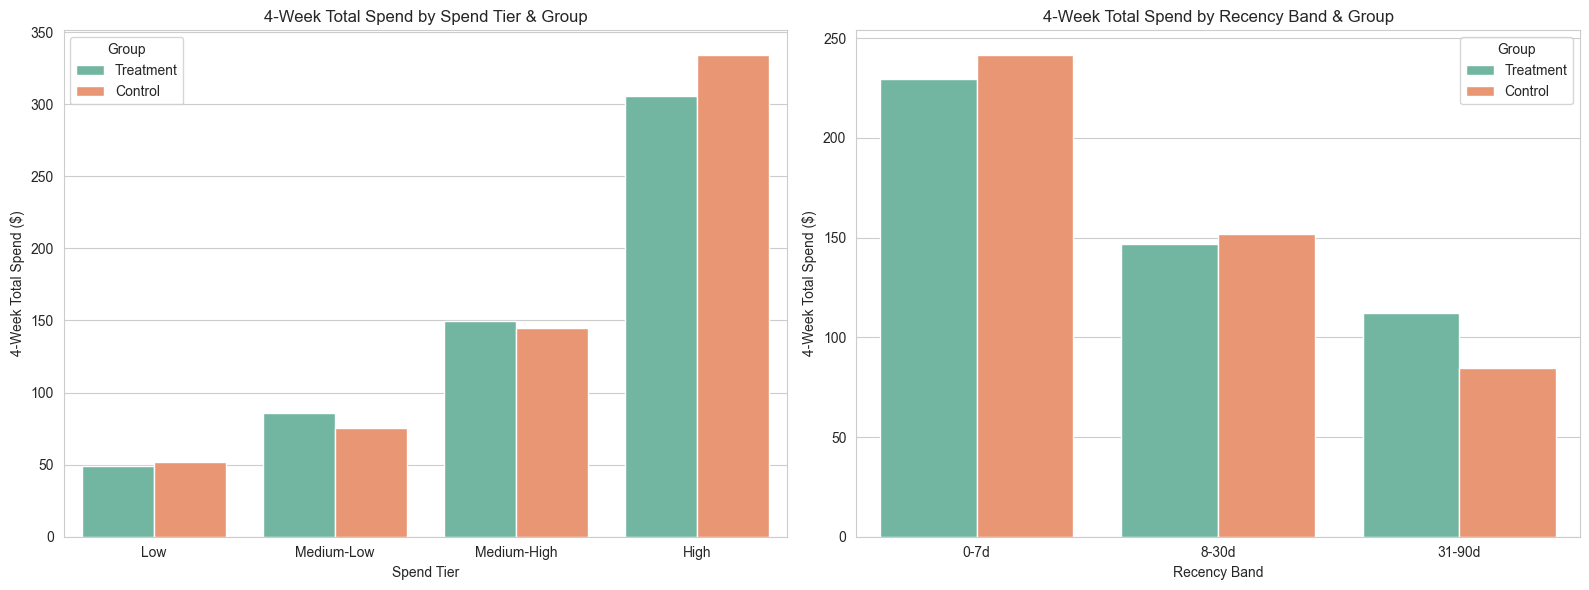

In [53]:
print("=" * 90)
print(f"SUBGROUP ANALYSIS BY SPEND TIER (Exploratory) — 4-Week Window (W{ws_mid}–{we_mid})")
print("=" * 90)
print(f"{'Spend Tier':<18} {'n_T':>6} {'n_C':>6} {'T Mean':>10} {'C Mean':>10} {'Diff':>10} {'p-value':>10}")
print("-" * 70)

for tier in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    t_sub = eligible[(eligible['group'] == 'Treatment') & (eligible['spend_tier'] == tier)]['spend_4wk']
    c_sub = eligible[(eligible['group'] == 'Control') & (eligible['spend_tier'] == tier)]['spend_4wk']
    
    if len(t_sub) > 1 and len(c_sub) > 1:
        _, p = stats.ttest_ind(t_sub, c_sub, equal_var=False)
        diff = t_sub.mean() - c_sub.mean()
        print(f"{tier:<18} {len(t_sub):>6} {len(c_sub):>6} {t_sub.mean():>10.2f} {c_sub.mean():>10.2f} {diff:>10.2f} {p:>10.4f}")

print("\nNote: With no actual treatment, differences are expected to be non-significant.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By spend tier
tier_data = []
for tier in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    for grp in ['Treatment', 'Control']:
        subset = eligible[(eligible['spend_tier'] == tier) & (eligible['group'] == grp)]
        tier_data.append({'Spend Tier': tier, 'Group': grp, 'Mean 4-Week Spend': subset['spend_4wk'].mean()})
tier_df = pd.DataFrame(tier_data)
sns.barplot(data=tier_df, x='Spend Tier', y='Mean 4-Week Spend', hue='Group', ax=axes[0], palette='Set2')
axes[0].set_title('4-Week Total Spend by Spend Tier & Group')
axes[0].set_ylabel('4-Week Total Spend ($)')

# By recency band
rec_data = []
for band in ['0-7d', '8-30d', '31-90d', '90d+']:
    for grp in ['Treatment', 'Control']:
        subset = eligible[(eligible['recency_band'] == band) & (eligible['group'] == grp)]
        if len(subset) > 0:
            rec_data.append({'Recency Band': band, 'Group': grp, 'Mean 4-Week Spend': subset['spend_4wk'].mean()})
rec_df = pd.DataFrame(rec_data)
sns.barplot(data=rec_df, x='Recency Band', y='Mean 4-Week Spend', hue='Group', ax=axes[1], palette='Set2')
axes[1].set_title('4-Week Total Spend by Recency Band & Group')
axes[1].set_ylabel('4-Week Total Spend ($)')

plt.tight_layout()
plt.show()

---
## Appendix E: Binary Outcome Power Analysis (Conversion Rate)

In addition to the continuous spend metric, we also consider power for a binary outcome: **conversion rate** (whether a household makes ≥1 purchase in the post-treatment window).

### Formula for Two-Proportion Z-Test

$$n_{\text{per arm}} = \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \left[ p_C(1-p_C) + p_T(1-p_T) \right]}{(p_T - p_C)^2}$$

where:
- $p_C$ = baseline conversion rate (control)
- $p_T$ = expected conversion rate under treatment = $p_C + \delta$
- $\delta$ = minimum detectable difference in proportions

In [55]:
def sample_size_two_proportion(p_c, p_t, alpha=0.05, power=0.80):
    """
    Sample size per arm for two-proportion z-test.
    
    n = (z_{1-α/2} + z_{1-β})² [p_C(1-p_C) + p_T(1-p_T)] / (p_T - p_C)²
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    delta = p_t - p_c
    n = ((z_alpha + z_beta) ** 2 * (p_c * (1 - p_c) + p_t * (1 - p_t))) / (delta ** 2)
    return int(np.ceil(n))

# Baseline conversion rate from the 4-week window (≥1 purchase)
baseline_conversion = (eligible['spend_4wk'] > 0).mean()
print(f"Baseline conversion rate (4-week window W{ws_mid}–{we_mid}): {baseline_conversion:.3f}")

# MDE scenarios for conversion
conv_mde_scenarios = [0.02, 0.03, 0.05, 0.07, 0.10]

print(f"\n{'MDE (pp)':<12} {'p_T':<10} {'n/arm (80%)':<15} {'n/arm (90%)':<15} {'Feasible?':<10}")
print("-" * 62)

for mde_pp in conv_mde_scenarios:
    p_t = baseline_conversion + mde_pp
    n_80 = sample_size_two_proportion(baseline_conversion, p_t, 0.05, 0.80)
    n_90 = sample_size_two_proportion(baseline_conversion, p_t, 0.05, 0.90)
    feasible = "Yes" if n_80 * 2 <= N_eligible else "No"
    print(f"{mde_pp:<12.2f} {p_t:<10.3f} {n_80:<15,} {n_90:<15,} {feasible:<10}")

print(f"\nAvailable: {N_eligible} eligible households ({N_eligible//2} per arm)")

Baseline conversion rate (4-week window W85–88): 0.922

MDE (pp)     p_T        n/arm (80%)     n/arm (90%)     Feasible? 
--------------------------------------------------------------
0.02         0.942      2,498           3,344           No        
0.03         0.952      1,033           1,382           No        
0.05         0.972      314             420             Yes       
0.07         0.992      130             173             Yes       
0.10         1.022      40              53              Yes       

Available: 1288 eligible households (644 per arm)
